In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")

PROJECT_ROOT = Path.cwd().parents[1]

RESULTS_DIR = PROJECT_ROOT / "results" / "sepsis" / "generated_trajectories"
DATA_DIR = PROJECT_ROOT / "data" / "processed"

training_metrics = pd.read_csv(RESULTS_DIR / "training_metrics.csv")
training_metrics.head()


,replicate,seed,epoch,train_total_loss,val_total_loss,train_fit_loss,val_fit_loss
0,1,42,1,3623.793010,3027.762586,3623.793010,3027.762586
1,1,42,2,3676.938162,2990.402881,3676.938162,2990.402881
2,1,42,3,3389.742156,2927.611881,3389.742156,2927.611881
3,1,42,4,3769.355934,2796.842851,3769.355934,2796.842851
4,1,42,5,3282.738689,2692.805573,3282.738689,2692.805573


In [3]:
runs = []
for n in range(5):
    run_n = pd.read_csv(RESULTS_DIR / f"replicate_0{n + 1}_seed_{n + 42}.csv")
    runs.append(run_n)
runs = pd.concat(runs, ignore_index=True)
display(runs["replicate"].unique())
runs_train = runs[runs["datasplit"] == "train"].copy()
runs_val = runs[runs["datasplit"] == "val"].copy()
runs.head()


array([1, 2, 3, 4, 5])

,model,tissue,start_sample,datasplit,replicate,seed,path_id,trajectory_replicate,step,t,protein,abundance,velocity
0,IP-Eco,Heart,TiM_P1908_122,train,1,42,0,0,0,0.00,Fga,23.528635,0.953536
1,IP-Eco,Heart,TiM_P1908_122,train,1,42,0,0,1,0.02,Fga,23.548232,1.006553
2,IP-Eco,Heart,TiM_P1908_122,train,1,42,0,0,2,0.04,Fga,23.568916,1.061966
3,IP-Eco,Heart,TiM_P1908_122,train,1,42,0,0,3,0.06,Fga,23.590727,1.119056
4,IP-Eco,Heart,TiM_P1908_122,train,1,42,0,0,4,0.08,Fga,23.613689,1.176802


In [ ]:
tissues = runs["tissue"].unique()
models = runs["model"].unique()
proteins = runs["protein"].unique()
n_tissues = len(tissues)
n_models = len(models)
n_proteins = len(proteins)
display(tissues)
display(models)

tissue_palette = {
    "Heart":      "#BD3961",  
    "Kidney":     "#5B526A", 
    "Leukocytes": "#36A259",  
    "Liver":      "#B85C45",  
    "Lungs":      "#7AA6C2",  
    "Plasma":     "#E684A6",  
    "Spleen":     "#8B5FBF",  
}

model_palette = {
    "IP-Eco": "#D671D1",
    "IP-Spy": "#3856B8",
    "IV-Sau": "#2E91C2",
    "SC-Spy": "#1E9B9A",
    "IN-Kpn": "#6D9F71",
    "IN-Spn": "#B17A45",
}


array(['Heart', 'Kidney', 'Leukocytes', 'Liver', 'Lungs', 'Plasma',
       'Spleen'], dtype=object)

array(['IP-Eco', 'IP-Spy', 'IV-Sau', 'SC-Spy', 'IN-Kpn', 'IN-Spn'],
      dtype=object)

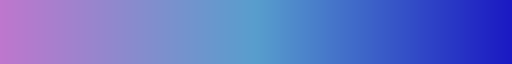

In [76]:
pink_cmap = sns.blend_palette(
    ["#BE77CE", "#589ECD", "#1B19C3"],
    as_cmap=True
)
pink_cmap

In [77]:
metadata = pd.read_csv(DATA_DIR / "mouse_sepsis_proteomics_metadata_batch_corrected.csv")
quant = pd.read_csv(DATA_DIR / "mouse_sepsis_proteomics_data_batch_corrected.csv")
annotations = pd.read_csv(DATA_DIR / "sepsis_uniprot_annotations.csv").fillna("")

rename_map = dict(zip(annotations["source_id"], annotations["display_name"]))
quant = quant.rename(columns=rename_map)

df = (
    quant.merge(metadata, on="Run", how="left")
    .rename(columns={"Model": "model", "Tissue": "tissue", "nhpi": "time", "hpi": "hpi"})
    .melt(
        id_vars=["Run", "model", "tissue", "time", "hpi"],
        var_name="protein",
        value_name="abundance",
    )
    .sort_values(["model", "tissue", "time", "Run", "protein"])
    .reset_index(drop=True)
)
df.head()


,Run,model,tissue,time,hpi,protein,abundance
0,Erik_M1908_085,IN-Kpn,Leukocytes,0.0,0,Acat2,20.160688
1,Erik_M1908_085,IN-Kpn,Leukocytes,0.0,0,Aco1,21.689276
2,Erik_M1908_085,IN-Kpn,Leukocytes,0.0,0,Aco2,22.988321
3,Erik_M1908_085,IN-Kpn,Leukocytes,0.0,0,Actr3,21.923648
4,Erik_M1908_085,IN-Kpn,Leukocytes,0.0,0,Afm,20.665359


In [78]:
quant

,Run,Fga,Gpx3,Itih4,C8b,Il1rap,Pgd,Fgb,Aldh1l1,Inhca,...,Prdx6,Lcp1,Psmb3,Ighm,Apoa4,Prdx2,Qsox1,Actr3,Ttr,Rad23b
0,TiM_P1908_122,24.169418,22.187340,20.595672,19.213242,19.762670,21.604985,24.378438,20.461797,21.192869,...,24.100461,21.288152,20.971221,22.229948,22.385311,25.273300,18.357645,21.617410,23.367354,20.987900
1,TiM_P1908_123,23.972207,22.194454,20.769525,18.655960,19.405099,21.554448,24.083284,21.012652,21.194877,...,24.051292,21.529720,20.880358,21.678027,22.455078,25.124972,18.614797,21.635629,23.498848,21.003149
2,TiM_P1908_124,22.699526,22.926276,21.472652,19.874192,20.237398,21.801781,22.403780,20.728452,21.976570,...,24.216721,21.059321,21.185242,22.882925,24.293080,26.177112,18.648463,21.553650,24.198313,20.974693
3,TiM_P1908_126,23.851742,22.385621,21.255448,19.216892,20.001525,21.857074,23.942546,21.625359,21.499489,...,23.994928,21.672740,20.947648,22.711876,21.817562,25.708741,18.913442,21.712677,23.814002,20.940657
4,TiM_P1908_127,22.321908,22.816009,21.747991,19.353796,20.488339,21.894605,22.102558,20.836030,22.152880,...,24.228410,20.827747,21.303530,23.203377,24.745909,26.293459,19.115622,21.597622,24.425650,21.061418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,ALE_M2004_217,25.357614,22.545517,24.145181,18.984615,20.064975,21.959857,25.247129,22.668058,21.305437,...,24.311936,22.476288,21.434198,22.818188,23.909097,25.009355,20.388417,21.557593,23.248062,21.279374
700,ALE_M2004_218,23.999766,21.693664,21.359904,18.108986,19.030852,21.342255,23.722310,22.648714,21.125348,...,24.162440,22.653727,21.006399,22.900730,22.417484,25.517682,19.096733,21.857756,23.025634,20.992291
701,ALE_M2004_219,24.690773,22.022937,22.129466,19.652044,19.607877,22.329897,24.618491,22.172376,21.674198,...,23.805838,22.646884,21.191256,22.428989,22.224531,25.867958,20.512402,21.718136,23.978872,20.944045
702,ALE_M2004_221,25.418316,21.940847,23.476054,20.141127,19.681643,22.356390,25.451926,22.552530,22.092910,...,23.950044,22.586881,20.825449,22.144512,22.787266,26.051916,20.968740,21.403092,23.761817,20.807917


# 0. Stability between runs
Check concordance of top proteins per tissue x model.


In [79]:
rank_tables = []
for n in range(5):
    run_n = runs_val[runs_val["replicate"] == n + 1].copy()
    run_ranks = (
        run_n.assign(abs_velocity=run_n["velocity"].abs())
        .groupby(["replicate", "model", "tissue", "protein"], observed=True)
        .agg(mean_abs_velocity=("abs_velocity", "mean"))
        .reset_index()
    )
    run_ranks["rank"] = (
        run_ranks.groupby(["replicate", "model", "tissue"], observed=True)["mean_abs_velocity"]
        .rank(method="first", ascending=False)
        .astype(int)
    )
    rank_tables.append(run_ranks)

ranks = (
    pd.concat(rank_tables, ignore_index=True)
    .sort_values(["model", "tissue", "replicate", "rank", "protein"])
    .reset_index(drop=True)
)
ranks = ranks[["replicate", "protein", "model", "tissue", "rank", "mean_abs_velocity"]]
ranks_agg = ranks.groupby(by=["protein", "model", "tissue"], as_index=False).agg(
    sd_rank=("rank", "std"),
    mean_rank=("rank", "mean"),
    mean_mean_abs_velocity=("mean_abs_velocity", "mean"),
)
ranks_agg.head()


,protein,model,tissue,sd_rank,mean_rank,mean_mean_abs_velocity
0,Acat2,IN-Kpn,Leukocytes,34.179672,135.250000,1.237143
1,Acat2,IN-Kpn,Lungs,23.352373,62.666667,0.881888
2,Acat2,IN-Kpn,Plasma,2.886751,6.333333,8.947188
3,Acat2,IN-Spn,Leukocytes,49.318354,143.400000,0.624748
4,Acat2,IN-Spn,Lungs,71.886716,87.800000,0.615740


Text(-2.958333333333334, 0.5, 'Velocity rank mean')

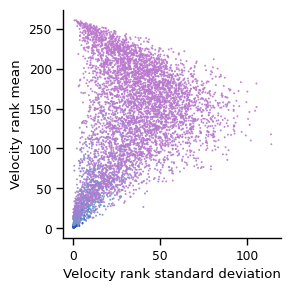

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(3, 3))
#sns.scatterplot(ranks_agg, x="mean_rank", y="mean_mean_abs_velocity", hue="tissue", palette=tissue_palette, s=3, linewidth=0, ax=axs[0])
sns.scatterplot(ranks_agg, x="sd_rank", y="mean_rank", s=2, linewidth=0, alpha=.9, hue="mean_mean_abs_velocity", palette=pink_cmap)
plt.legend().remove()
sns.despine()
plt.tight_layout()
plt.xlabel("Velocity rank standard deviation")
plt.ylabel("Velocity rank mean")

# 0.1 How well do models predict?

In [81]:
t_bins = [0.1, 0.25, 0.5, 0.75, 1]
t_labels = [f"{start:.2f}-{end:.2f}" for start, end in zip(t_bins[:-1], t_bins[1:])]

actual_long = (
    df.assign(t_window=pd.cut(df["time"], bins=t_bins, labels=t_labels, include_lowest=True))
    .groupby(["model", "tissue", "protein", "t_window"], observed=True)
    .agg(actual=("abundance", "mean"))
    .reset_index()
)

predicted_long = (
    runs_val.assign(t_window=pd.cut(runs_val["t"], bins=t_bins, labels=t_labels, include_lowest=True))
    .groupby(["model", "tissue", "protein", "t_window"], observed=True)
    .agg(predicted=("abundance", "mean"))
    .reset_index()
)

prediction_summary = (
    actual_long.merge(predicted_long, on=["model", "tissue", "protein", "t_window"], how="inner")
    .sort_values(["model", "tissue", "t_window", "protein"])
    .reset_index(drop=True)
)
prediction_summary.head()

,model,tissue,protein,t_window,actual,predicted
0,IN-Kpn,Leukocytes,Acat2,0.10-0.25,20.467885,21.184292
1,IN-Kpn,Leukocytes,Aco1,0.10-0.25,21.537712,21.731790
2,IN-Kpn,Leukocytes,Aco2,0.10-0.25,22.852659,22.962695
3,IN-Kpn,Leukocytes,Actr3,0.10-0.25,21.679462,21.625451
4,IN-Kpn,Leukocytes,Afm,0.10-0.25,20.443887,21.306333


0.9504040916048897
0.9580251687807976
0.9516283481943204
0.9496076632645118


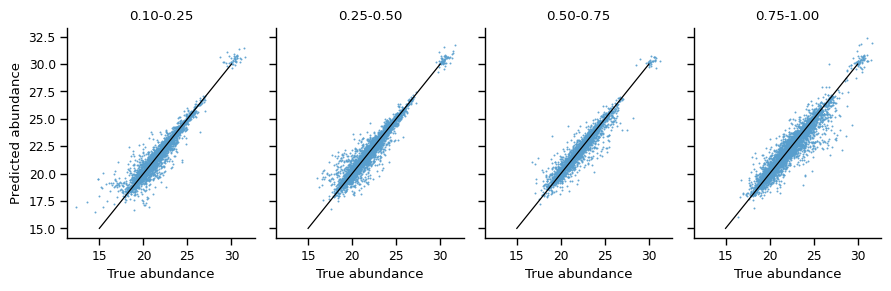

In [ ]:
from scipy.stats import pearsonr
fig, axs = plt.subplots(1, len(t_labels), figsize=(9,3), sharex=True, sharey=True)
for i, t_window in enumerate(t_labels):
    ax=axs[i]
    predicted_t_window = prediction_summary[prediction_summary["t_window"] == t_window]
    sns.scatterplot(predicted_t_window, x="actual", y="predicted", ax=ax, s=2, linewidth=0, alpha=0.9, color="#589ECD")
    p,t = pearsonr(predicted_t_window["actual"], predicted_t_window["predicted"])
    print(p)
    ax.set_title(t_window)
    ax.plot([15,30],[15,30], color="k", linewidth=0.9)
    ax.set_xlabel("True abundance")
    ax.set_ylabel("Predicted abundance")

sns.despine()
plt.tight_layout()

np.float64(0.9590794017543466)

np.float64(0.035691815972089085)

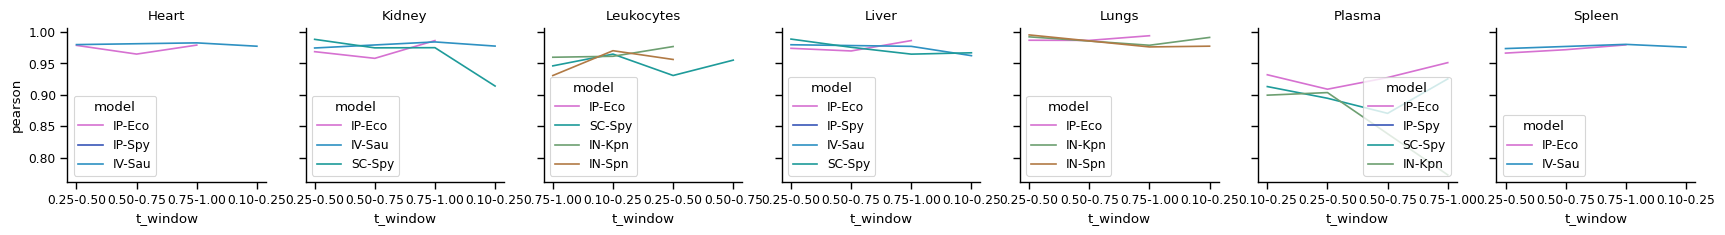

In [83]:
from scipy.stats import pearsonr

fig, axs = plt.subplots(1, n_tissues, figsize=(n_tissues*3,2), sharey=True)
pearsons = []
for i, t in enumerate(tissues):
    tissue_results = {"model":[], "pearson":[], "t_window":[]}
    ax = axs[i]
    predicted_tissue = prediction_summary[prediction_summary["tissue"] == t]
    for model in models:
        predicted_model = predicted_tissue[predicted_tissue["model"] == model]
        for t_window in t_labels:
            predicted_t_window = predicted_model[predicted_model["t_window"] == t_window]
            if len(predicted_t_window) > 0:
                statistic, p_val = pearsonr(predicted_t_window["actual"], predicted_t_window["predicted"])
                tissue_results["model"].append(model)
                tissue_results["t_window"].append(t_window)
                tissue_results["pearson"].append(statistic)
                pearsons.append(statistic)

    sns.lineplot(tissue_results, x="t_window",y="pearson", hue="model", palette=model_palette, ax=ax)
    ax.set_title(t)
display(np.mean(pearsons), np.std(pearsons))
sns.despine()

# 1. Plot some UMAPs

In [84]:
from umap import UMAP

shared_proteins = sorted(set(df["protein"]).intersection(runs["protein"]))

real_wide = (
    df[df["protein"].isin(shared_proteins)]
    .pivot_table(
        index=["Run", "model", "tissue", "time"],
        columns="protein",
        values="abundance",
    )
    .reindex(columns=shared_proteins)
    .reset_index()
    .rename(columns={"Run": "sample", "time": "t"})
)
real_wide["sample_type"] = "real"
real_wide["replicate"] = pd.NA

generated_wide = (
    runs_val[runs_val["protein"].isin(shared_proteins)]
    .pivot_table(
        index=["replicate", "model", "tissue", "start_sample", "path_id", "trajectory_replicate", "step", "t", "datasplit"],
        columns="protein",
        values="abundance",
    )
    .reindex(columns=shared_proteins)
    .reset_index()
)
generated_wide["sample"] = (
    "generated_"
    + generated_wide["replicate"].astype(str)
    + "_"
    + generated_wide["path_id"].astype(str)
    + "_"
    + generated_wide["trajectory_replicate"].astype(str)
    + "_"
    + generated_wide["step"].astype(str)
)
generated_wide["sample_type"] = "generated"

embedding_input = pd.concat(
    [
        real_wide[["sample", "sample_type", "t", "model", "tissue", "replicate", *shared_proteins]],
        generated_wide[["sample", "sample_type", "t", "model", "tissue", "replicate", *shared_proteins]],
    ],
    ignore_index=True,
)

umap_embedder = UMAP(random_state=42)
umap_embedder.fit(real_wide[shared_proteins])
embedding = umap_embedder.transform(embedding_input[shared_proteins])

umap_df = embedding_input[["sample", "sample_type", "t", "model", "tissue", "replicate"]].copy()
umap_df["umap1"] = embedding[:, 0]
umap_df["umap2"] = embedding[:, 1]
umap_df.head()

/Users/erikhartman/dev/flow-matching/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


protein,sample,sample_type,t,model,tissue,replicate,umap1,umap2
0,ALE_M2004_166,real,0.00,IV-Sau,Heart,<NA>,2.907994,3.975650
1,ALE_M2004_167,real,0.25,IV-Sau,Heart,<NA>,5.695115,3.567367
2,ALE_M2004_168,real,0.50,IV-Sau,Heart,<NA>,7.487425,2.644480
3,ALE_M2004_169,real,1.00,IV-Sau,Heart,<NA>,7.980365,0.138991
4,ALE_M2004_171,real,0.00,IV-Sau,Heart,<NA>,2.579692,3.306236


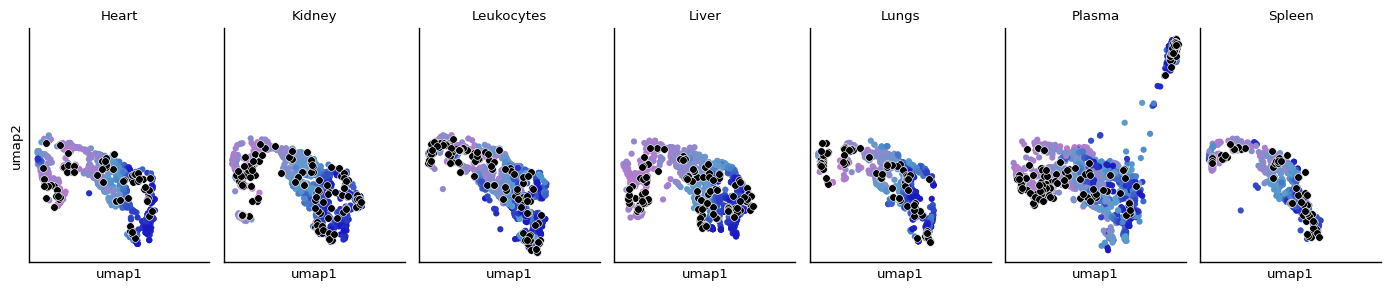

In [85]:
fig, axs = plt.subplots(1, n_tissues, figsize=(n_tissues*2,3), sharex=True, sharey=True)
for i, t in enumerate(tissues):
    umap_t = umap_df[umap_df["tissue"] == t]
    
    sns.scatterplot(umap_t[umap_t["sample_type"] == "generated"], x="umap1", y="umap2", hue="t", ax=axs[i], s=20, linewidth=0, palette=pink_cmap)
    sns.scatterplot(umap_t[umap_t["sample_type"] == "real"], x="umap1", y="umap2", ax=axs[i], s=30, color="k")
    axs[i].set_title(t)

for ax in axs.ravel():
    
    ax.legend().remove()
    ax.set_xticks([])
    ax.set_yticks([])
    
sns.despine()
plt.tight_layout()
#plt.savefig("/Users/erikhartman/dev/flow-matching/panels/trajectory_umap.svg", bbox_inches="tight")

# 2. Velocity profiles

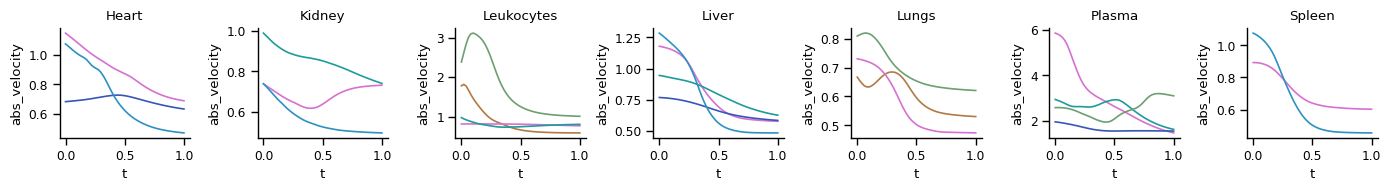

In [86]:
runs_val = runs_val.copy()
runs_val["abs_velocity"] = runs_val["velocity"].abs()
runs_val["velocity_contrast"] = (
    runs_val["velocity"]
    - runs_val.groupby(["replicate", "t", "protein"], observed=True)["velocity"].transform("mean")
)
runs_val["abs_velocity_contrast"] = runs_val["velocity_contrast"].abs()

fig, axs = plt.subplots(1, n_tissues, figsize=(n_tissues * 2, 2))
for i, tissue in enumerate(tissues):
    ax = axs[i]
    run_t = runs_val[runs_val["tissue"] == tissue]
    sns.lineplot(run_t, x="t", y="abs_velocity", hue="model", palette=model_palette, ax=ax, errorbar=None)
    ax.set_title(tissue)
    sns.despine(ax=ax)

    ax.legend().remove()
plt.tight_layout()


# 3. Top proteins


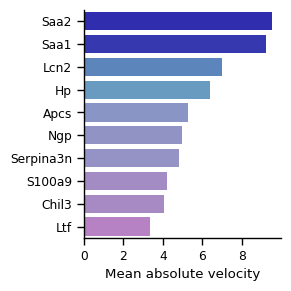

In [ ]:
top_proteins_df = runs_val[["protein", "abs_velocity"]].groupby("protein", as_index=False).mean().sort_values(by="abs_velocity", ascending=False).head(10)

plt.figure(figsize=(3,3))
sns.barplot(top_proteins_df, y="protein", x="abs_velocity", hue="abs_velocity", palette=pink_cmap)
sns.despine()
plt.legend().remove()
plt.xlabel("Mean absolute velocity")
plt.ylabel("")
plt.tight_layout()

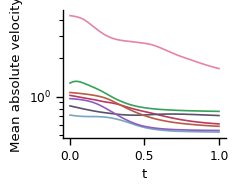

In [ ]:
plt.figure(figsize=(2.5,2))
sns.lineplot(runs_val, y="abs_velocity", x="t", hue="tissue",
             errorbar=None, palette=tissue_palette)
sns.despine()
plt.yscale("log")
plt.legend().remove()
plt.xlabel("t")
plt.ylabel("")
plt.ylabel("Mean absolute velocity")
plt.tight_layout()

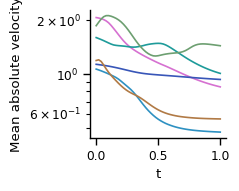

In [ ]:
plt.figure(figsize=(2.5,2))
sns.lineplot(runs_val, y="abs_velocity", x="t", hue="model", 
             errorbar=None, palette=model_palette)
sns.despine()
plt.yscale("log")
plt.legend().remove()
plt.ylabel("Mean absolute velocity")
plt.xlabel("t")
plt.tight_layout()

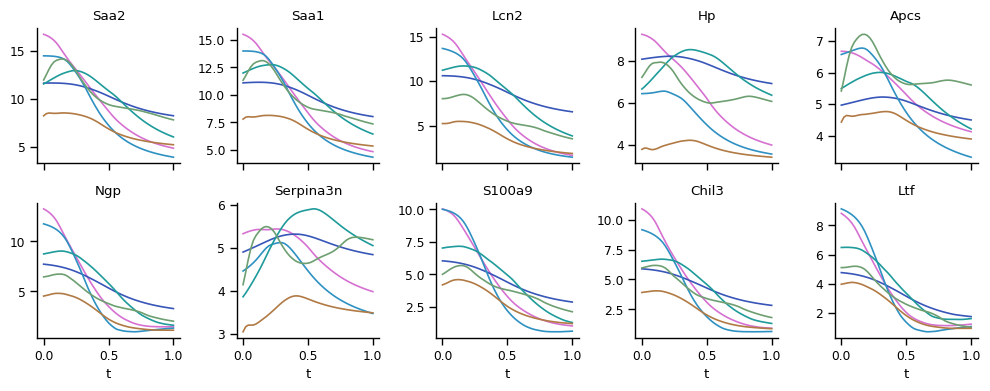

In [ ]:
top_proteins = (
    runs_val[["protein", "abs_velocity"]]
    .groupby("protein")
    .mean()["abs_velocity"]
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

fig, axs = plt.subplots(2, 5, figsize=(len(top_proteins), 4), sharex=True)
for i, ax in zip(enumerate(top_proteins), axs.ravel()):
    i,p = i
    run_p = runs_val[runs_val["protein"] == p]
    sns.lineplot(run_p, x="t", y="abs_velocity", hue="model", palette=model_palette, ax=ax, errorbar=None)
    sns.despine(ax=ax)
    ax.set_title(p)
    ax.legend().remove()
    ax.set_ylabel("")
    
plt.tight_layout()

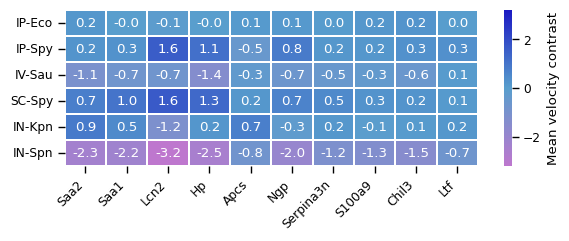

In [ ]:
top_proteins_contrast_heatmap = (
    runs_val[runs_val["protein"].isin(top_proteins)]
    .groupby(["model", "protein"], observed=True)
    .agg(velocity_contrast=("velocity_contrast", "mean"))
    .reset_index()
    .pivot(index="model", columns="protein", values="velocity_contrast")
    .reindex(index=models, columns=top_proteins)
)

contrast_limit = np.nanmax(np.abs(top_proteins_contrast_heatmap.to_numpy()))

plt.figure(figsize=(6,2.5))
ax = sns.heatmap(
    top_proteins_contrast_heatmap,
    cmap=pink_cmap,
    center=0,
    vmin=-contrast_limit,
    vmax=contrast_limit,
    linewidths=0.3,
    annot=True,
    fmt=".1f",
    linecolor="white",
    cbar_kws={"label": "Mean velocity contrast"},
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()

In [92]:
# pairwise velocity profile correlation
velocity_profile_cols = [
    "model",
    "tissue",
    "start_sample",
    "replicate",
    "seed",
    "path_id",
    "trajectory_replicate",
]

velocity_profile_wide = (
    runs_val.pivot_table(
        index=velocity_profile_cols,
        columns=["protein", "t"],
        values="velocity",
    )
    .sort_index()
    .sort_index(axis=1)
)

velocity_profile_corr = velocity_profile_wide.T.corr()

/Users/erikhartman/dev/flow-matching/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/erikhartman/dev/flow-matching/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


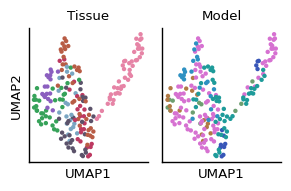

In [ ]:
velocity_profile_distance = (1 - velocity_profile_corr).clip(lower=0).to_numpy()
np.fill_diagonal(velocity_profile_distance, 0)

velocity_profile_umap = UMAP(metric="precomputed", random_state=42, n_neighbors=20, min_dist=.5).fit_transform(
    velocity_profile_distance
)

velocity_profile_umap_df = velocity_profile_wide.index.to_frame(index=False)
velocity_profile_umap_df["umap1"] = velocity_profile_umap[:, 0]
velocity_profile_umap_df["umap2"] = velocity_profile_umap[:, 1]

fig, axs = plt.subplots(1,2, figsize=(3,2), sharex=True, sharey=True)

sns.scatterplot(
    velocity_profile_umap_df,
    x="umap1",
    y="umap2",
    hue="tissue",
    palette=tissue_palette,
    s=10,
    linewidth=0,
    ax=axs[0],
)
axs[0].set_title("Tissue")

sns.scatterplot(
    velocity_profile_umap_df,
    x="umap1",
    y="umap2",
    hue="model",
    palette=model_palette,
    s=10,
    linewidth=0,
    ax=axs[1],
)
axs[1].set_title("Model")

for ax in axs:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    sns.despine(ax=ax)
    ax.legend().remove()
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

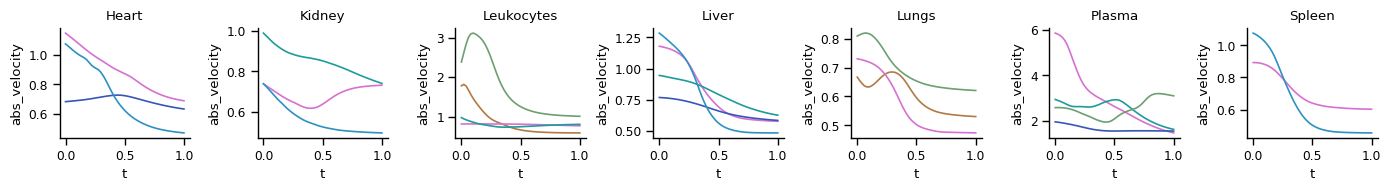

In [94]:
fig, axs = plt.subplots(1, n_tissues, figsize=(n_tissues * 2, 2))
for i, tissue in enumerate(tissues):
    ax = axs[i]
    run_t = runs_val[runs_val["tissue"] == tissue]
    sns.lineplot(run_t, x="t", y="abs_velocity", hue="model", palette=model_palette, ax=ax, errorbar=None)
    ax.set_title(tissue)
    sns.despine(ax=ax)

    ax.legend().remove()
plt.tight_layout()


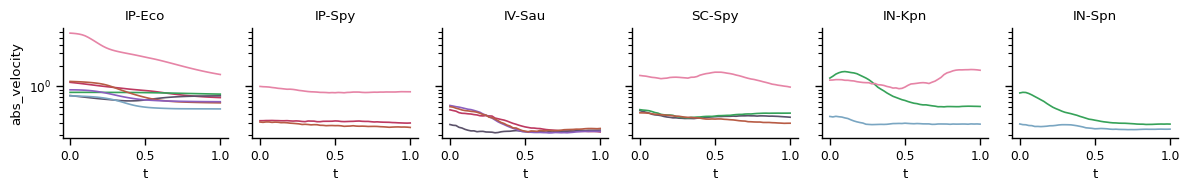

In [95]:
fig, axs = plt.subplots(1, n_models, figsize=(n_models * 2, 2), sharey=True)
for i, model in enumerate(models):
    ax = axs[i]
    run_t = runs_val[runs_val["model"] == model]
    sns.lineplot(run_t, x="t", y="abs_velocity", hue="tissue", palette=tissue_palette, ax=ax, errorbar=None)
    ax.set_title(model)
    sns.despine(ax=ax)
    ax.set_yscale("log")
    ax.legend().remove()
plt.tight_layout()


In [96]:
# time when velocity peaks for each protein and sample (runs_val)
sample_cols = [
    "model",
    "tissue",
    "start_sample",
    "replicate",
    "seed",
    "path_id",
    "trajectory_replicate",
    "protein",
]

peak_velocity_times = (
    runs_val.loc[
        runs_val.groupby(sample_cols, observed=True)["abs_velocity"].idxmax(),
        sample_cols + ["step", "t", "abs_velocity", "abundance"],
    ]
    .rename(
        columns={
            "step": "step_peak_velocity",
            "t": "t_peak_velocity",
            "abs_velocity": "peak_velocity",
            "abundance": "abundance_at_peak_velocity",
        }
    )
    .sort_values(sample_cols)
    .reset_index(drop=True)
)

peak_velocity_times.head()

,model,tissue,start_sample,replicate,seed,path_id,trajectory_replicate,protein,step_peak_velocity,t_peak_velocity,peak_velocity,abundance_at_peak_velocity
0,IN-Kpn,Leukocytes,Erik_M1908_086,4,45,14,0,Acat2,0,0.00,1.712114,20.629009
1,IN-Kpn,Leukocytes,Erik_M1908_086,4,45,14,0,Aco1,0,0.00,5.007609,22.419556
2,IN-Kpn,Leukocytes,Erik_M1908_086,4,45,14,0,Aco2,0,0.00,1.367638,22.664174
3,IN-Kpn,Leukocytes,Erik_M1908_086,4,45,14,0,Actr3,0,0.00,1.545113,21.831148
4,IN-Kpn,Leukocytes,Erik_M1908_086,4,45,14,0,Afm,8,0.16,3.634336,21.585855


/var/folders/64/ytcycnwx6w936vfxs5_7q3hm0000gn/T/ipykernel_95797/1634758664.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


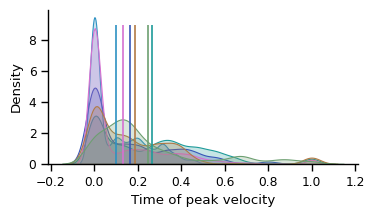

In [ ]:
top_proteins = (
    runs_val[["protein", "abs_velocity"]]
    .groupby("protein")
    .mean()["abs_velocity"]
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)
plt.figure(figsize=(4,2))

sns.kdeplot(peak_velocity_times[peak_velocity_times["protein"].isin(top_proteins)], x="t_peak_velocity", hue="model", common_norm=False, palette=model_palette, fill=True, bw_adjust=0.5)
plt.legend().remove()
peak_means = {}
for model in models:
    pvt = peak_velocity_times[peak_velocity_times["protein"].isin(top_proteins)]
    pvt_model = pvt[pvt["model"] == model]
    pvt_model_mean = pvt_model["t_peak_velocity"].mean()
    plt.vlines([pvt_model_mean], ymin=0, ymax=9, color=model_palette[model])
    peak_means["model"] = pvt_model_mean

plt.xlabel(r"Time of peak velocity")
sns.despine()

In [98]:
peak_values = {"model": [], "n": [], "t_peak_velocity": [], "tissue":[]}

for n in range(1, 200):
    top_proteins = (
        runs_val[["protein", "abs_velocity"]]
        .groupby("protein")
        .mean()["abs_velocity"]
        .sort_values(ascending=False)
        .head(n)
        .index
        .tolist()
    )

    for model in models:
        pvt = peak_velocity_times[
            peak_velocity_times["protein"].isin(top_proteins)
        ]
        pvt_model = pvt[pvt["model"] == model]
        for tissue in tissues:
            pvt_tissue = pvt_model[pvt_model["tissue"] == tissue]

            for val in pvt_tissue["t_peak_velocity"]:
                peak_values["model"].append(model)
                peak_values["n"].append(n)
                peak_values["t_peak_velocity"].append(val)
                peak_values["tissue"].append(tissue)

temp_df = pd.DataFrame(peak_values)
temp_df.head()

,model,n,t_peak_velocity,tissue
0,IP-Eco,1,0.28,Heart
1,IP-Eco,1,0.02,Heart
2,IP-Eco,1,0.50,Heart
3,IP-Eco,1,0.38,Heart
4,IP-Eco,1,0.42,Heart


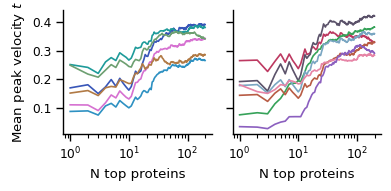

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(4, 2), sharex=True, sharey=True)

sns.lineplot(
    data=temp_df,
    x="n",
    y="t_peak_velocity",
    hue="model",
    palette=model_palette,
    errorbar=None,
    ax=axs[0]
)
sns.lineplot(
    data=temp_df,
    x="n",
    y="t_peak_velocity",
    hue="tissue",
    palette=tissue_palette,
    errorbar=None,
    ax=axs[1],
)
axs[0].set_ylabel(r"Mean peak velocity $t$")

for ax in axs.ravel():
    ax.set_xlabel("N top proteins")
    ax.set_xscale("log")
    ax.legend().remove()

sns.despine()
plt.tight_layout()